In [1]:
from pypalace import Config, Simulation,Tools
from pypalace.builder import Model, Domains, Boundaries, Solver

Define paths

In [2]:
''' path to Palace executable ''' 
path_to_palace = "/Users/firasabouzahr/Desktop/AWSPalace/install/bin/palace-arm64.bin" # change to your path

''' path to mesh files / where we will save generated config files '''
mesh_dir = "mesh/"
config_dir = "config/"

''' path to mesh file + name of config file we will generate in pyPalace'''
xmon_meshfile = mesh_dir + "xmon.bdf"
xmon_path_to_json = config_dir + "xmon-electrostatic_sim.json"

# Create Palace config file with pyPalace

Take a look at mesh attributes to help generate config

In [3]:
mesh_attributes = Tools.get_mesh_attributes(xmon_meshfile)
mesh_attributes

,Name,ID,Type
0,substrate,1,Volume
1,air,2,Volume
2,qubit,3,Surface
3,claw,4,Surface
4,ground_plane,5,Surface
5,far_field,6,Surface


Instantiate config object + add Config["Problem"] & add Config["Model"] blocks 

In [4]:
''' Define config object '''
xmon_config = Config(xmon_path_to_json)

''' Problem and Model '''
xmon_config.add_Problem(Type="Electrostatic",Output="xmon_electro_output")
xmon_config.add_Model(xmon_meshfile) # no AMR, meshed finely already

Define Materials & Add Config["Domains"] Block

In [5]:
''' Materials '''
silicon = Domains.Material([1],1.0,11.45,0.0) # silicon 
air = Domains.Material([2],1.0,1.0,0.0) # air
xmon_config.add_Domains(Materials=[silicon,air]) # add the materials

Define Boundary Conditions & Add Config["Boundaries"] Block

In [6]:
''' Boundary Conditions '''
## terminals ##
cross_terminal = Boundaries.Terminal(Index=1,Attributes=[3]) # qubit cross
claw_terminal = Boundaries.Terminal(Index=2,Attributes=[4]) # claw

## Ground ##
Grounds = Boundaries.Ground(Attributes=[5,6]) # ground plane, far field

''' Boundary Postprocessing '''
cross_sf = Boundaries.Postprocessing_SurfaceFlux(Index=1,Attributes=[3],Type="Electric")
claw_sf = Boundaries.Postprocessing_SurfaceFlux(Index=2,Attributes=[4],Type="Electric")

my_BCs = [cross_terminal,claw_terminal,Grounds]
my_BC_postprocessing = [cross_sf,claw_sf]

## add boundary conditions and boundary postprocessing
xmon_config.add_Boundaries(BCs=my_BCs,Postprocessing=my_BC_postprocessing)

Define Solver parameters & Add Config["Solver"] block

In [7]:
''' electrostatic simulation and linear solver paramters ''' 
electro_params = Solver.Electrostatic(Save=3)

Linear_params = Solver.Linear(Type="BoomerAMG",
                              KSPType = "CG",
                              Tol = 1e-6, # make more stringent for better results
                              MaxIts = 25) 
                              
xmon_config.add_Solver(Simulation=electro_params,
                       Order= 2, # second order solver
                       Linear=Linear_params)

Take a peak at the config file

In [8]:
xmon_config.print_config()

{
  "Problem": {
    "Type": "Electrostatic",
    "Verbose": 2,
    "Output": "xmon_electro_output"
  },
  "Model": {
    "Mesh": "mesh/xmon.bdf",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          1
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 0.0
      },
      {
        "Attributes": [
          2
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "Ground": {
      "Attributes": [
        5,
        6
      ]
    },
    "Terminal": [
      {
        "Index": 1,
        "Attributes": [
          3
        ]
      },
      {
        "Index": 2,
        "Attributes": [
          4
        ]
      }
    ],
    "Postprocessing": {
      "SurfaceFlux": [
        {
          "Index": 1,
          "Attributes": [
            3
          ],
          "Type": "Electric"
        },
        {
          "Index": 2,
          

# Run the simulation

In [9]:
''' run the simulation '''
xmon_simulation = Simulation(xmon_config,path_to_palace)
xmon_simulation.run(n=5) # 5 mpi processses

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (xmon_electro_output)
Git changeset ID: v0.13.0-509-g360de9ab
Running with 5 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 76 elements in 1 iterations of local bisection for under-resolved interior boundaries
Added 4508 duplicate vertices for interior boundaries in the mesh
Added 10363 duplicate boundary elements for interior boundaries in the mesh
Finished partitioning mesh into 5 subdomains

Characteristic length and time scales:
 L₀ = 1.000e-03 m, t₀ = 3.336e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-4.000e-04, -4.000e-04, -5.000e-04) m
 (Xmax, Ymax, Zmax) = (+4.000e-04, +4.000e-04, +5.000e-04) m

Parallel Mes

visualize the electric potential, $V$.

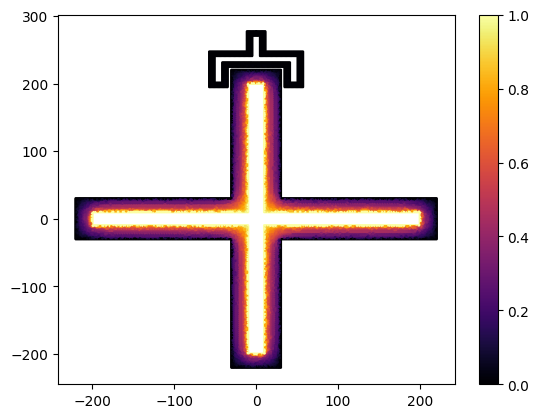

In [10]:
xmon_simulation.plot_field(field="V",index=0)

pyPalace has some built-in extraction tools for common simulation deliverables

In [11]:
capacitance_matrix = xmon_simulation.get_capacitance_matrix()

# Lumped Oscillator Analysis to extract Hamiltonian parameters

### Calculate $C_\Sigma$ and choose $L_J$ for LOM analysis

We choose an Josephson junction inductance, $L_J = 14$ nH

In [12]:
C00 = capacitance_matrix.iloc[0,0]

C_Sigma = C00
LJ = 14e-09 # 14 nH

In [13]:
from pypalace.analysis import LOM
Hamiltonian_params = LOM.get_Hamiltonian_parameters(C_Sigma,LJ)
Hamiltonian_params

{'frequency_GHz': 3.883712713172048, 'anharmonicity_MHz': -199.30928245193172}